# Differentiable quantile functions

jax has CDFs for the classic distributions but not their inverses, and
the requests go back years: gammaincinv (jax#2399), betaincinv
(jax#5350), the Student-t pair stdtr/stdtrit (jax#20358). chebax
provides all of them as jittable functions with gradients in every
argument, including the shape parameters.

The gradients come from the implicit function theorem applied at the
solution, never from differentiating through the solver iteration, so
they are as accurate as the CDF itself.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy.special as sps

jax.config.update("jax_enable_x64", True)

import chebax

## Values

A quick cross-check against scipy's implementations.

betaincinv(2, 3, p)    max abs diff vs scipy: 1.34e-14
gammaincinv(2, p)      max abs diff vs scipy: 2.13e-14
stdtrit(4, p)          max abs diff vs scipy: 7.53e-14


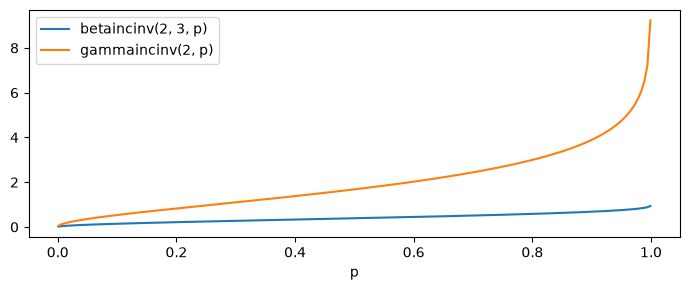

In [2]:
p = np.linspace(0.001, 0.999, 200)
a, b, df = 2.0, 3.0, 4.0

pairs = [
    ("betaincinv(2, 3, p)", chebax.betaincinv(a, b, p), sps.betaincinv(a, b, p)),
    ("gammaincinv(2, p)", chebax.gammaincinv(a, p), sps.gammaincinv(a, p)),
    ("stdtrit(4, p)", chebax.stdtrit(df, p), sps.stdtrit(df, p)),
]
for name, ours, ref in pairs:
    print(f"{name:22s} max abs diff vs scipy: {np.max(np.abs(np.asarray(ours) - ref)):.2e}")

plt.figure(figsize=(7, 3))
for name, ours, _ in pairs[:2]:
    plt.plot(p, ours, label=name)
plt.xlabel("p")
plt.legend()
plt.tight_layout()

## Tail resolution

The solvers work in log or logit space, so tail quantiles stay resolved
far past where an x-space iteration would saturate. The Gamma quantile
is good all the way down to p = 1e-300:

In [3]:
ps = jnp.asarray([1e-300, 1e-100, 1e-10])
print("gammaincinv(2, p):", np.asarray(chebax.gammaincinv(2.0, ps)))
print("scipy:            ", sps.gammaincinv(2.0, np.asarray(ps)))

gammaincinv(2, p): [1.41421356e-150 1.41421356e-050 1.41422023e-005]
scipy:             [1.41421356e-150 1.41421356e-050 1.41422023e-005]


and the Beta quantile through p = 1e-20:

In [4]:
ps = jnp.asarray([1e-5, 1e-10, 1e-20])
print("betaincinv(2, 3, p):", np.asarray(chebax.betaincinv(a, b, ps)))
print("scipy:              ", sps.betaincinv(a, b, np.asarray(ps)))

betaincinv(2, 3, p): [1.29210742e-03 4.08249402e-06 4.08248290e-11]
scipy:               [1.29210742e-03 4.08249402e-06 4.08248290e-11]


## Gradients in the degrees of freedom

A concrete use: the two-sided 95% Student-t critical value as a function
of the degrees of freedom, and its derivative. Both are one `vmap` away.

grad at nu=4: -0.2737436774, central diff: -0.2737436777


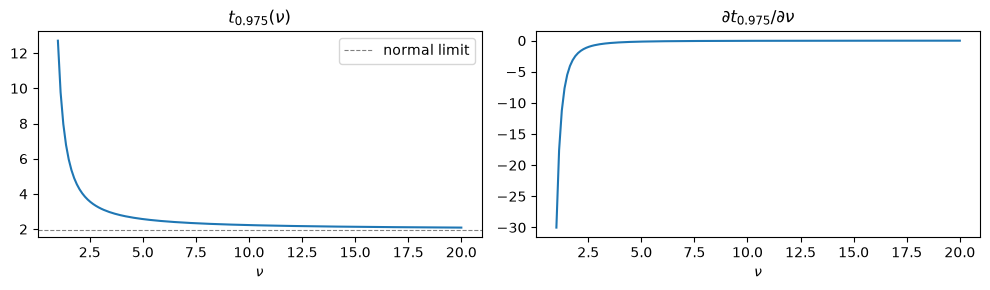

In [5]:
nus = jnp.linspace(1.0, 20.0, 150)
crit = jax.vmap(lambda n: chebax.stdtrit(n, 0.975))(nus)
dcrit = jax.vmap(jax.grad(lambda n: chebax.stdtrit(n, 0.975)))(nus)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(nus, crit)
ax1.axhline(1.959964, color="gray", lw=0.8, ls="--", label="normal limit")
ax1.set_xlabel(r"$\nu$")
ax1.set_title(r"$t_{0.975}(\nu)$")
ax1.legend()
ax2.plot(nus, dcrit)
ax2.set_xlabel(r"$\nu$")
ax2.set_title(r"$\partial t_{0.975} / \partial \nu$")
plt.tight_layout()

# check one point against a central difference
n0, h = 4.0, 1e-6
fd = (sps.stdtrit(n0 + h, 0.975) - sps.stdtrit(n0 - h, 0.975)) / (2 * h)
print(f"grad at nu=4: {float(jax.grad(lambda n: chebax.stdtrit(n, 0.975))(n0)):.10f}, "
      f"central diff: {fd:.10f}")

## Reparameterized sampling

With a differentiable quantile function, `x = F^{-1}(u; theta)` with
u ~ Uniform(0,1) is a pathwise-differentiable sample: gradients of a
Monte Carlo expectation flow into the shape parameters. For Beta(a, b)
the mean is a/(a+b), so d E[x] / da = b/(a+b)^2 gives an exact target.

In [6]:
u = jax.random.uniform(jax.random.PRNGKey(0), (40000,))

def mc_mean(a_):
    return chebax.betaincinv(a_, b, u).mean()

g_mc = jax.grad(mc_mean)(a)
g_exact = b / (a + b) ** 2
print(f"d E[x]/da: reparameterized MC {float(g_mc):.5f}, exact {g_exact:.5f} "
      f"(MC error is O(1/sqrt(n)))")

d E[x]/da: reparameterized MC 0.12008, exact 0.12000 (MC error is O(1/sqrt(n)))


## Continuous degrees of freedom: the chi-square quantile

gammaincinv gives the chi-square quantile at any real dof,
chi2_q(k, p) = 2 * gammaincinv(k/2, p), differentiable in k. Useful
whenever the dof itself is a learned or optimized quantity.

chi2_q(5, 0.95) = 11.070498  (scipy: 11.070498)


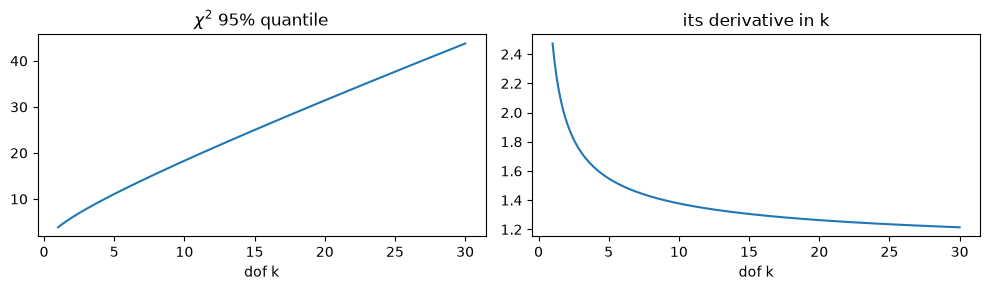

In [7]:
def chi2_quantile(k, p):
    return 2.0 * chebax.gammaincinv(k / 2.0, p)

ks = jnp.linspace(1.0, 30.0, 200)
q95 = jax.vmap(lambda k: chi2_quantile(k, 0.95))(ks)
dq95 = jax.vmap(jax.grad(lambda k: chi2_quantile(k, 0.95)))(ks)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(ks, q95)
ax1.set_xlabel("dof k")
ax1.set_title(r"$\chi^2$ 95% quantile")
ax2.plot(ks, dq95)
ax2.set_xlabel("dof k")
ax2.set_title("its derivative in k")
plt.tight_layout()

print(f"chi2_q(5, 0.95) = {float(chi2_quantile(5.0, 0.95)):.6f}  "
      f"(scipy: {2 * sps.gammaincinv(2.5, 0.95):.6f})")